# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [ ]:
import sys, os, gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import torch
from sklearn.model_selection import cross_validate 


import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc
from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest
from stellar_classification.utils.seeding import set_seed

#seed
SEED = 42

set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Enable garbage collection
gc.enable()
gc.collect()

/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
 18  u_g          100000 non-

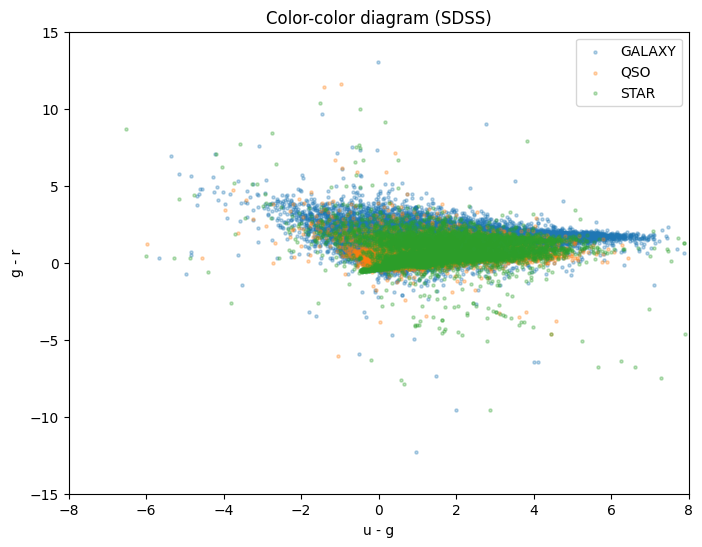

In [ ]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

# Color indexes 
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]


print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()



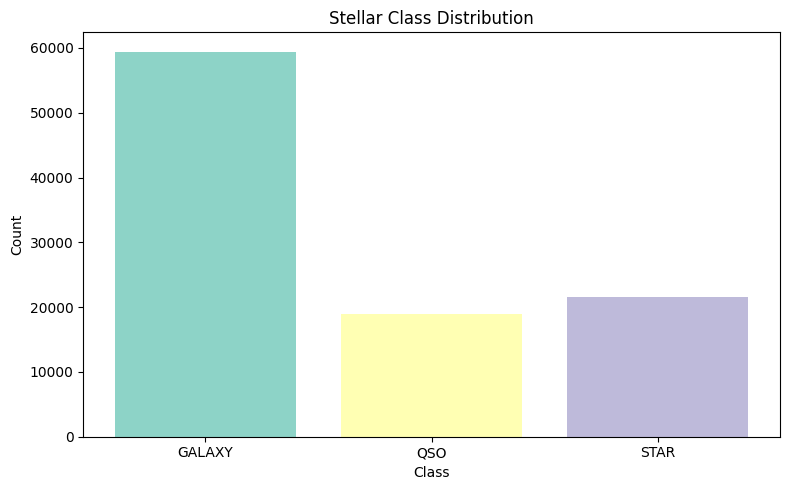

In [3]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [4]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    label_encoder,
    scaler,
    feature_names,
    pca,
) = sc.prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True
)

class_names = list(label_encoder.classes_)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print(feature_names)

Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 9)
X_val shape: (18257, 9)
X_test shape: (18257, 9)
['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z']


## Random Forest and Extra Trees 

In [ ]:
import importlib, sys
to_remove = [k for k in sys.modules if 'stellar_classification' in k]
for k in to_remove:
    del sys.modules[k]
import stellar_classification as sc

In [ ]:
#hyper parameter tuning and training best model for random forest and extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': None, 'max_depth': 25}
Acc=97.5585 P=0.9756 R=0.9756 F1=0.9756
Confusion Matrix:
[[31361   561   422]
 [  468 31698   178]
 [  455   285 31604]]

Acc=88.4318 P=0.8521 R=0.8576 F1=0.8544
Confusion Matrix:
[[10005   423   353]
 [  267  2998   283]
 [  398   388  3142]]

Extra Trees best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Acc=94.4451 P=0.9450 R=0.9445 F1=0.9444
Confusion Matrix:
[[31141   735   468]
 [ 1073 30760   511]
 [ 1207  1396 29741]]

Acc=88.7660 P=0.8585 R=0.8605 F1=0.8583
Confusion Matrix:
[[10061   410   310]
 [  259  3075   214]
 [  425   433  3070]]



In [8]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)


Random Forest:
  Accuracy  : 88.79%
  Precision: 0.8553
  Recall   : 0.8623
  F1       : 0.8584
  Confusion Matrix:
[[10025   396   360]
 [  243  3018   287]
 [  370   391  3167]]

Extra Trees:
  Accuracy  : 88.95%
  Precision: 0.8592
  Recall   : 0.8633
  F1       : 0.8603
  Confusion Matrix:
[[10061   392   328]
 [  241  3080   227]
 [  401   429  3098]]


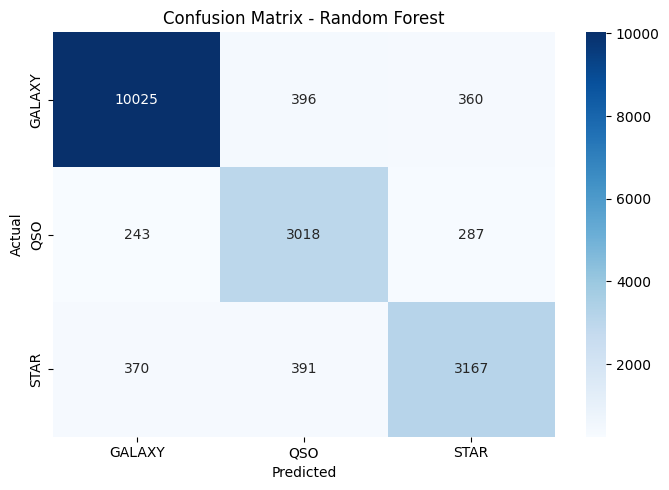

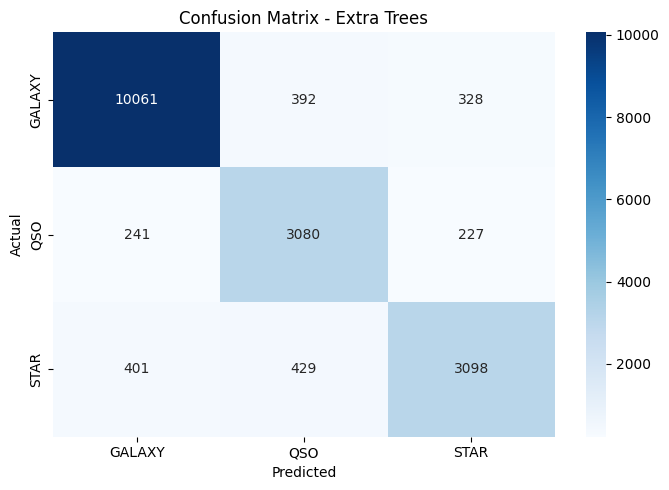

In [ ]:
#confusion matrix for the best models of random forest and extra trees

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Extra Trees')

           RANDOM FOREST — Feature Importance


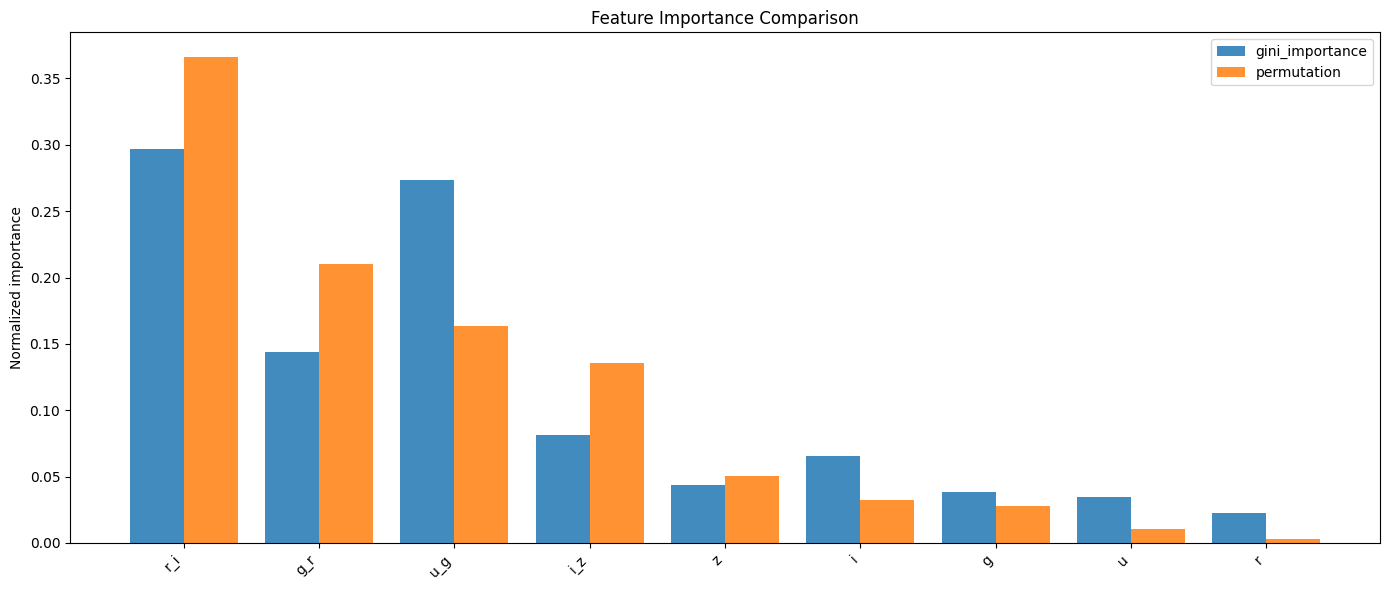


 Feature Importance Scores:


,gini_importance,permutation
r_i,0.296728,0.366430
g_r,0.144062,0.210551
u_g,0.273193,0.163304
i_z,0.081264,0.135387
z,0.043873,0.050799
i,0.065872,0.032574
g,0.038447,0.027615
u,0.034275,0.010256
r,0.022285,0.003084


           EXTRA TREES — Feature Importance


In [ ]:
#feature importance for the best models of random forest and extra trees

importance_functions= {
    "gini_importance": lambda m: m.feature_importances_
}



print("           RANDOM FOREST — Feature Importance")
df_imp_rf = sc.plot_feature_importance(
    rf_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)


print("           EXTRA TREES — Feature Importance")
df_imp_et = sc.plot_feature_importance(
    et_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)


## XGBoost and LightGBM

In [ ]:
#hyperparameter tuning of xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=3)

params = {"n_estimators": [300,500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb, best_params_xgb, best_score_xgb = sc.tune_model(
    xgb,
    params,
    X_train,
    y_train,
)

print("Best Hyperparameters:", best_params_xgb)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [ ]:
#xgboost training best model with early stopping and evaluation on validation set

best_params_xgb.pop("n_estimators", None)
best_params_xgb.pop("max_depth", None)

xgb_final = XGBClassifier(**best_params_xgb,n_estimators=1000,max_depth=7, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],verbose=False)

train_metrics_xgb, val_metrics_xgb = sc.evaluate_single_model(
    xgb_final,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb = xgb_final.predict(X_test)
xgb_metrics = sc.evaluate_test_set(y_test, y_test_pred_xgb, "XGBoost")
sc.print_metrics(xgb_metrics)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

[Training] Acc=92.4149% P=0.9243 R=0.9241 F1=0.9241
Confusion Matrix:
[[30495   922   927]
 [ 1407 29732  1205]
 [ 1443  1456 29445]]

[Validation] Acc=88.5797% P=0.8531 R=0.8619 F1=0.8570
Confusion Matrix:
[[9973  428  380]
 [ 245 3028  275]
 [ 376  381 3171]]


XGBoost:
  Accuracy  : 89.18%
  Precision: 0.8598
  Recall   : 0.8692
  F1       : 0.8641
  Confusion Matrix:
[[10013   405   363]
 [  239  3044   265]
 [  328   375  3225]]


In [ ]:
#hyperparameter tuning of lightgbm

import os
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=3,verbose=-1)
params = {"n_estimators": [300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm, best_params_lgbm, best_score_lgbm = sc.tune_model(
    lgbm,
    params,
    X_train,
    y_train,verbose=False
)

print("Best Hyperparameters:", best_params_lgbm)
 

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [ ]:
#lgbm training best model with early stopping and evaluation on validation set

best_params_lgbm.pop("n_estimators", None)
best_params_lgbm.pop("max_depth", None)
lgbm_final = LGBMClassifier(**best_params_lgbm,n_estimators=1000,max_depth=5,verbose=-1 )

import lightgbm as lgb
lgbm_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final,
    X_train, y_train,
    X_val, y_val,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm = lgbm_final.predict(X_test)
lgbm_metrics = sc.evaluate_test_set(y_test, y_test_pred_lgbm, "LightGBM")
sc.print_metrics(lgbm_metrics)

X_test_df = pd.DataFrame(X_test, columns=feature_names)



Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[420]	valid_0's multi_logloss: 0.327265
[Training] Acc=91.3894% P=0.9141 R=0.9139 F1=0.9138
Confusion Matrix:
[[30319  1022  1003]
 [ 1549 29394  1401]
 [ 1574  1806 28964]]

[Validation] Acc=88.3771% P=0.8498 R=0.8605 F1=0.8545
Confusion Matrix:
[[9942  441  398]
 [ 236 3037  275]
 [ 369  403 3156]]


LightGBM:
  Accuracy  : 88.89%
  Precision: 0.8555
  Recall   : 0.8678
  F1       : 0.8612
  Confusion Matrix:
[[9956  424  401]
 [ 239 3038  271]
 [ 316  377 3235]]


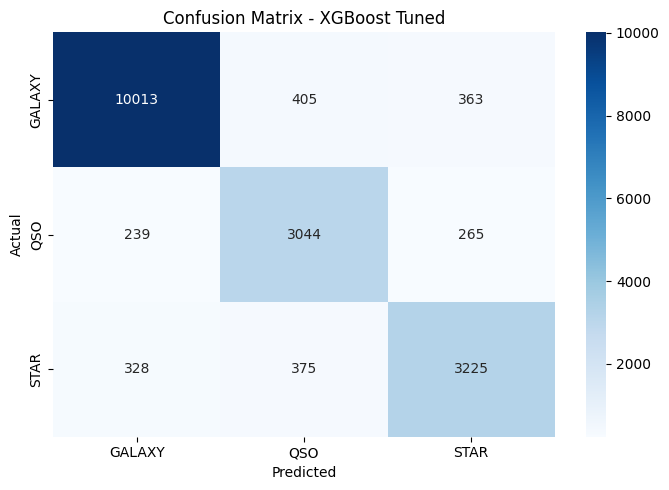

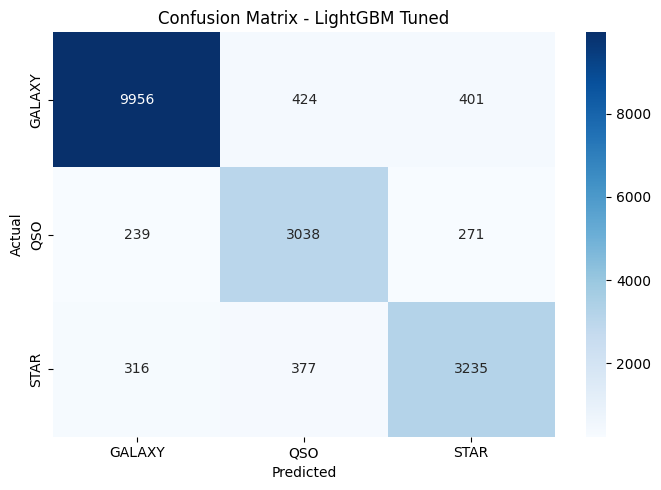

In [ ]:
#confusion matrix for the best models of xgboost and lightgbm
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(xgb_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - XGBoost Tuned')
sc.plot_confusion_matrix(lgbm_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - LightGBM Tuned')

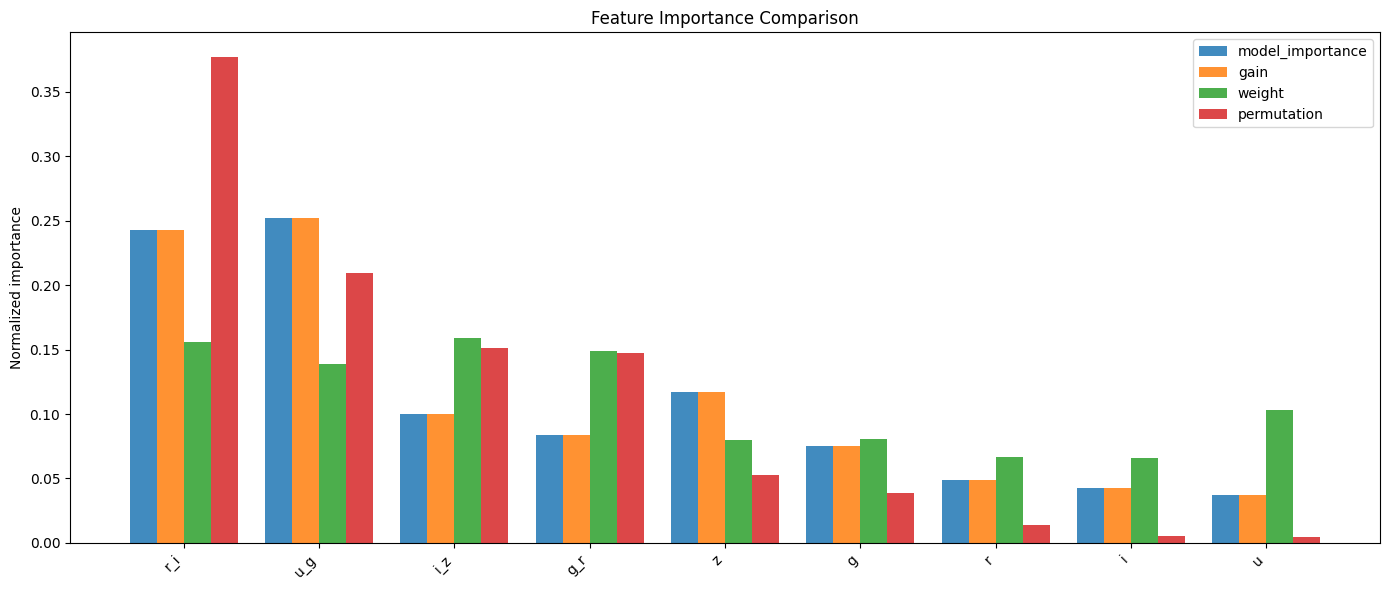


 Feature Importance Scores:


,model_importance,gain,weight,permutation
r_i,0.242853,0.242853,0.155604,0.377187
u_g,0.252321,0.252321,0.138913,0.209053
i_z,0.099788,0.099788,0.159297,0.151391
g_r,0.084113,0.084113,0.149161,0.147093
z,0.116926,0.116926,0.080176,0.052703
g,0.075525,0.075525,0.080975,0.038676
r,0.048807,0.048807,0.066954,0.013779
i,0.042412,0.042412,0.065659,0.005183
u,0.037255,0.037255,0.103261,0.004934


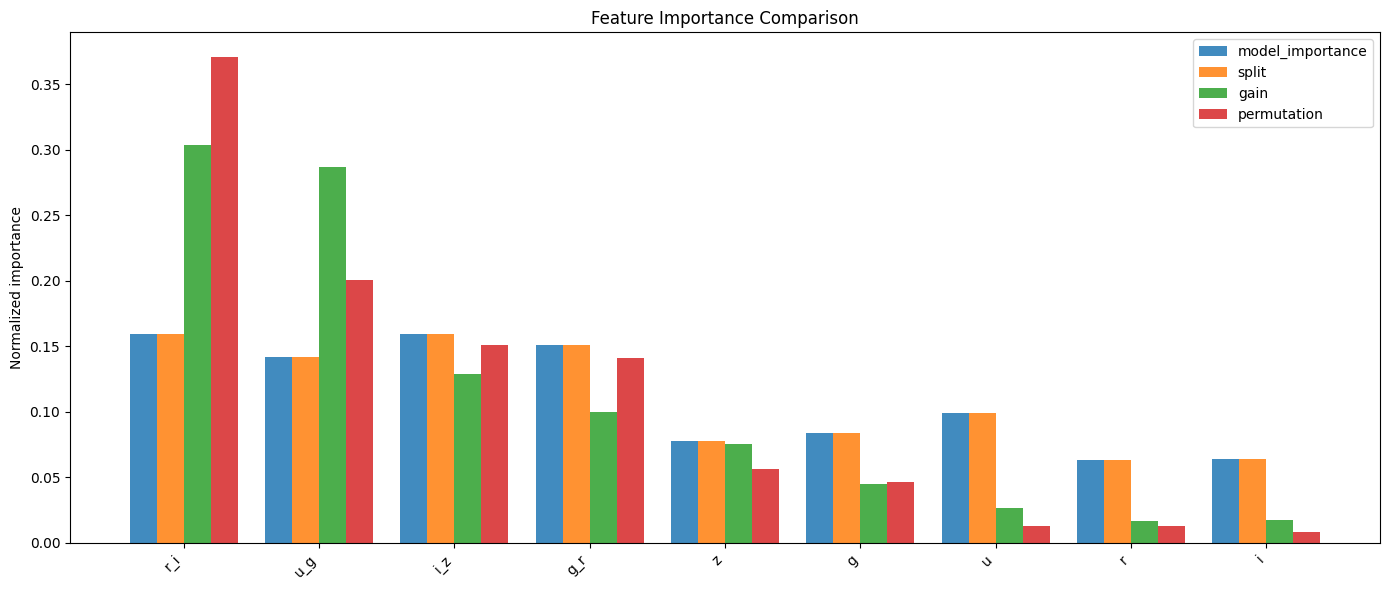


 Feature Importance Scores:


,model_importance,split,gain,permutation
r_i,0.159493,0.159493,0.303492,0.370862
u_g,0.142079,0.142079,0.286706,0.200638
i_z,0.159147,0.159147,0.128514,0.150997
g_r,0.150757,0.150757,0.099551,0.140908
z,0.077930,0.077930,0.075143,0.056777
g,0.083984,0.083984,0.045124,0.046327
u,0.099294,0.099294,0.026772,0.012853
r,0.063053,0.063053,0.017095,0.012582
i,0.064264,0.064264,0.017602,0.008055


In [ ]:
#feature importance for the best models of xgboost and lightgbm

importance_functions_xgb = {

    "model_importance":
        lambda m: m.feature_importances_,

    "gain":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="gain"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ]),

    "weight":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="weight"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ])
}

df_imp = sc.plot_feature_importance(
    xgb_final,
    feature_names,
    prefix_name="XGBoost",

    importance_functions=importance_functions_xgb,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)


importance_functions_lgbm = {

    # sklearn-style importance
    "model_importance":
        lambda m: m.feature_importances_,

    # numero split
    "split":
        lambda m: m.booster_.feature_importance(
            importance_type="split"
        ),

    # gain totale
    "gain":
        lambda m: m.booster_.feature_importance(
            importance_type="gain"
        )
}

df_imp = sc.plot_feature_importance(
    lgbm_final,
    feature_names,
    prefix_name="LightGBM",

    importance_functions=importance_functions_lgbm,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)


# Neural Networks


In [5]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)


print("DataLoaders created.")


DataLoaders created.


In [6]:
# Neural Network setup

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Input size:", input_size)
print("Number of classes:", num_classes)

Input size: 9
Number of classes: 3


In [7]:
# Run Neural Network Experiments

results_df = sc.run_experiments(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,

    input_size=input_size,
    num_classes=num_classes,

    model_types=[
        "SimpleNN",
        "MediumNN",
        "ComplexNN",
    ],

    learning_rates=[
        0.01,
        0.001,
        0.0001,
    ],

    epochs=15,
)


Training SimpleNN | lr=0.01
Epoch 1/15 | loss=0.4556 | train_acc=82.99% | val_acc=85.42%
Epoch 2/15 | loss=0.4131 | train_acc=84.50% | val_acc=84.83%
Epoch 3/15 | loss=0.3950 | train_acc=85.27% | val_acc=87.71%
Epoch 4/15 | loss=0.3889 | train_acc=85.43% | val_acc=87.58%
Epoch 5/15 | loss=0.3840 | train_acc=85.60% | val_acc=86.54%
Epoch 6/15 | loss=0.3802 | train_acc=85.68% | val_acc=86.02%
Epoch 7/15 | loss=0.3772 | train_acc=85.84% | val_acc=87.86%
Epoch 8/15 | loss=0.3755 | train_acc=85.96% | val_acc=87.20%
Epoch 9/15 | loss=0.3754 | train_acc=85.90% | val_acc=86.17%
Epoch 10/15 | loss=0.3741 | train_acc=85.88% | val_acc=87.53%
Epoch 11/15 | loss=0.3729 | train_acc=86.00% | val_acc=87.84%
Epoch 12/15 | loss=0.3717 | train_acc=85.99% | val_acc=88.16%
Epoch 13/15 | loss=0.3708 | train_acc=86.14% | val_acc=86.03%
Epoch 14/15 | loss=0.3702 | train_acc=86.17% | val_acc=85.58%
Epoch 15/15 | loss=0.3693 | train_acc=86.06% | val_acc=87.16%
✔ Done: SimpleNN | lr=0.01 | loss=0.3693 | train_a

In [8]:
# Results
display(results_df)


,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,history
4,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.316995,87.630885,89.001479,87.713332,0.878075,0.877133,0.876712,89.001479,0.860390,0.862340,0.861228,89.450622,0.865271,0.867270,0.866085,"{'train_loss': [0.44817626580409337, 0.3809076..."
6,ComplexNN,0.0100,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.342113,87.173304,88.519472,86.980584,0.871598,0.869806,0.869189,88.519472,0.855987,0.856994,0.855272,88.826204,0.859475,0.859797,0.858444,"{'train_loss': [0.43236079127401916, 0.3825653..."
7,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.278344,89.189133,88.283946,89.542625,0.895784,0.895426,0.895276,88.283946,0.848949,0.859896,0.853877,88.782385,0.854685,0.865822,0.859744,"{'train_loss': [0.40803234636705016, 0.3548278..."
3,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.330650,87.371177,88.147012,87.748372,0.877748,0.877484,0.877191,88.147012,0.846743,0.858545,0.852197,88.453744,0.849486,0.861908,0.855041,"{'train_loss': [0.41596808255543893, 0.3713153..."
0,SimpleNN,0.0100,SimpleNN(\n (net): Sequential(\n (0): Line...,0.369304,86.062330,87.161089,86.630184,0.866328,0.866302,0.866101,87.161089,0.834530,0.854718,0.843815,87.725256,0.840552,0.860196,0.849625,"{'train_loss': [0.4555935667644776, 0.41306720..."
5,MediumNN,0.0001,MediumNN(\n (net): Sequential(\n (0): Line...,0.367149,85.888161,87.407570,85.865488,0.858903,0.858655,0.858133,87.407570,0.838626,0.850434,0.843712,87.856712,0.843008,0.856234,0.848890,"{'train_loss': [0.6291247188809206, 0.46351005..."
1,SimpleNN,0.0010,SimpleNN(\n (net): Sequential(\n (0): Line...,0.359652,86.351925,87.067974,86.457045,0.865763,0.864570,0.864087,87.067974,0.834179,0.852807,0.841388,87.407570,0.836867,0.856128,0.844430,"{'train_loss': [0.5072274648325964, 0.44126260..."
8,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.312742,87.878226,85.780796,87.141355,0.873960,0.871414,0.871324,85.780796,0.815694,0.854650,0.830767,86.503807,0.823687,0.860729,0.837948,"{'train_loss': [0.47668269847322625, 0.3846174..."
2,SimpleNN,0.0001,SimpleNN(\n (net): Sequential(\n (0): Line...,0.436264,83.937258,85.287835,83.942411,0.839721,0.839424,0.838789,85.287835,0.811980,0.832140,0.820183,85.561702,0.813882,0.835323,0.822912,"{'train_loss': [0.6986082098007831, 0.55550308..."


In [9]:
best_simple = results_df[results_df["model"] == "SimpleNN"].iloc[0]
best_medium = results_df[results_df["model"] == "MediumNN"].iloc[0]
best_complex = results_df[results_df["model"] == "ComplexNN"].iloc[0]


In [ ]:
# 

dropout_results = sc.experiments.nn_runner.run_dropout_ablation(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    input_size=input_size,
    num_classes=num_classes,
    results_df=results_df,
    dropout_values=(0.2, 0.3, 0.5),
    epochs=15,
)



Best configuration for MediumNN: lr=0.001 | val_f1=0.8612

Dropout test → MediumNN | lr=0.001 | dropout=0.2
Epoch 1/15 | loss=0.4801 | train_acc=81.68% | val_acc=86.99%
Epoch 2/15 | loss=0.4077 | train_acc=84.55% | val_acc=87.66%
Epoch 3/15 | loss=0.3908 | train_acc=85.08% | val_acc=87.65%
Epoch 4/15 | loss=0.3798 | train_acc=85.55% | val_acc=87.82%
Epoch 5/15 | loss=0.3732 | train_acc=85.70% | val_acc=87.98%
Epoch 6/15 | loss=0.3679 | train_acc=85.93% | val_acc=88.44%
Epoch 7/15 | loss=0.3627 | train_acc=86.15% | val_acc=88.24%
Epoch 8/15 | loss=0.3600 | train_acc=86.26% | val_acc=88.05%
Epoch 9/15 | loss=0.3566 | train_acc=86.28% | val_acc=88.56%
Epoch 10/15 | loss=0.3533 | train_acc=86.45% | val_acc=88.17%
Epoch 11/15 | loss=0.3516 | train_acc=86.52% | val_acc=88.80%
Epoch 12/15 | loss=0.3504 | train_acc=86.52% | val_acc=88.84%
Epoch 13/15 | loss=0.3483 | train_acc=86.76% | val_acc=88.72%
Epoch 14/15 | loss=0.3477 | train_acc=86.68% | val_acc=88.45%
Epoch 15/15 | loss=0.3459 | trai

In [11]:
dropout_results.sort_values(by="val_f1", ascending=False).head(10)

,model,learning_rate,dropout,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,history
0,MediumNN,0.001,0.2,MediumNN(\n (net): Sequential(\n (0): Line...,0.345907,86.770344,88.738566,87.408278,0.876329,0.874083,0.873457,88.738566,0.857859,0.861670,0.858117,89.121981,0.861722,0.865563,0.861845,"{'train_loss': [0.48012989321349087, 0.4076980..."
1,MediumNN,0.001,0.3,MediumNN(\n (net): Sequential(\n (0): Line...,0.362563,86.199398,88.574245,87.078490,0.873010,0.870785,0.870098,88.574245,0.855508,0.859420,0.855636,88.913841,0.859175,0.863946,0.859874,"{'train_loss': [0.4964820207461921, 0.42320333..."
2,MediumNN,0.001,0.5,MediumNN(\n (net): Sequential(\n (0): Line...,0.403650,84.843145,88.245604,86.216918,0.866198,0.862169,0.861092,88.245604,0.852758,0.854736,0.850711,88.311333,0.852830,0.855207,0.851052,"{'train_loss': [0.5521126576431031, 0.46493837..."
3,ComplexNN,0.010,0.2,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.533333,81.002144,86.147779,84.336095,0.844810,0.843361,0.842671,86.147779,0.819223,0.835017,0.826603,86.470943,0.822906,0.838209,0.830079,"{'train_loss': [0.5081457967379412, 0.48399038..."
4,ComplexNN,0.010,0.3,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.607190,78.132987,84.340253,81.183527,0.833688,0.811835,0.804898,84.340253,0.828716,0.801390,0.794939,84.696281,0.829108,0.806358,0.799838,"{'train_loss': [0.5529014881732202, 0.54601704..."
5,ComplexNN,0.010,0.5,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.896898,55.907330,70.077231,60.366683,0.416687,0.603667,0.488311,70.077231,0.440561,0.603449,0.493101,70.148436,0.441234,0.604229,0.493568,"{'train_loss': [0.7117959658763247, 0.69754507..."


In [12]:
best_medium_dropout = dropout_results[dropout_results["model"] == "MediumNN"].iloc[0]
best_complex_dropout = dropout_results[dropout_results["model"] == "ComplexNN"].iloc[0]

In [13]:
final_sorted = sc.get_final_candidates(
    results_df=results_df,
    dropout_results=dropout_results,
    top_k=3
)

display(final_sorted)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,history,dropout
0,MediumNN,0.001,MediumNN(\n (net): Sequential(\n (0): Line...,0.316995,87.630885,89.001479,87.713332,0.878075,0.877133,0.876712,89.001479,0.860390,0.862340,0.861228,89.450622,0.865271,0.867270,0.866085,"{'train_loss': [0.44817626580409337, 0.3809076...",NaN
3,MediumNN,0.001,MediumNN(\n (net): Sequential(\n (0): Line...,0.345907,86.770344,88.738566,87.408278,0.876329,0.874083,0.873457,88.738566,0.857859,0.861670,0.858117,89.121981,0.861722,0.865563,0.861845,"{'train_loss': [0.48012989321349087, 0.4076980...",0.2
4,MediumNN,0.001,MediumNN(\n (net): Sequential(\n (0): Line...,0.362563,86.199398,88.574245,87.078490,0.873010,0.870785,0.870098,88.574245,0.855508,0.859420,0.855636,88.913841,0.859175,0.863946,0.859874,"{'train_loss': [0.4964820207461921, 0.42320333...",0.3
1,ComplexNN,0.010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.342113,87.173304,88.519472,86.980584,0.871598,0.869806,0.869189,88.519472,0.855987,0.856994,0.855272,88.826204,0.859475,0.859797,0.858444,"{'train_loss': [0.43236079127401916, 0.3825653...",NaN
2,ComplexNN,0.001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.278344,89.189133,88.283946,89.542625,0.895784,0.895426,0.895276,88.283946,0.848949,0.859896,0.853877,88.782385,0.854685,0.865822,0.859744,"{'train_loss': [0.40803234636705016, 0.3548278...",NaN
5,MediumNN,0.001,MediumNN(\n (net): Sequential(\n (0): Line...,0.403650,84.843145,88.245604,86.216918,0.866198,0.862169,0.861092,88.245604,0.852758,0.854736,0.850711,88.311333,0.852830,0.855207,0.851052,"{'train_loss': [0.5521126576431031, 0.46493837...",0.5



MediumNN:
  Accuracy  : 89.45%
  Precision: 0.8653
  Recall   : 0.8673
  F1       : 0.8661
  Confusion Matrix:
[[10120   336   325]
 [  268  3004   276]
 [  363   358  3207]]


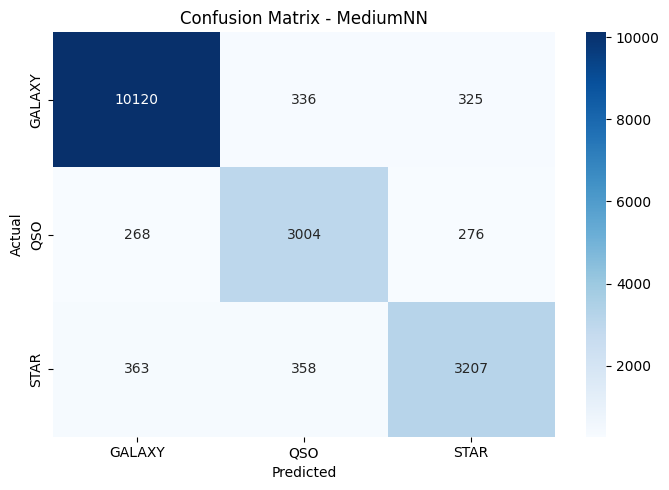

In [ ]:
# Best model NN
best_model_row = final_sorted.iloc[0]

best_metrics = sc.evaluate_neural(
    test_loader=test_loader,
    model=best_model_row["trained_model"],
    device=sc.device,
    model_name=f"{best_model_row['model']}"
)

# metrics
sc.print_metrics(best_metrics)

# Confusion matrix for the best NN model
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    class_names=class_names,
    title=f"Confusion Matrix - {best_model_row['model']}"
)


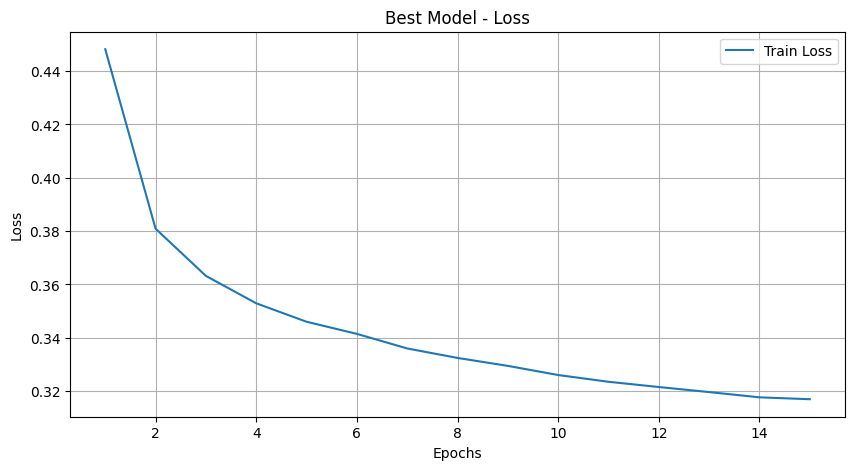

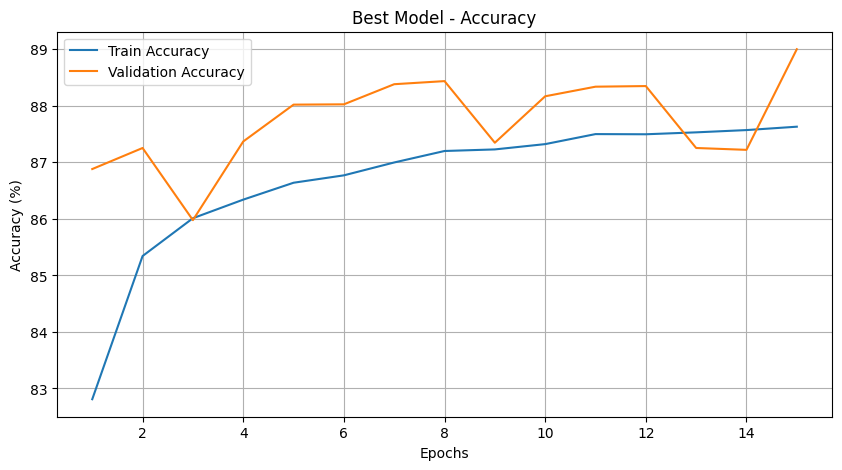

In [15]:
sc.plot_training_history(best_model_row["history"], title="Best Model")

1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257


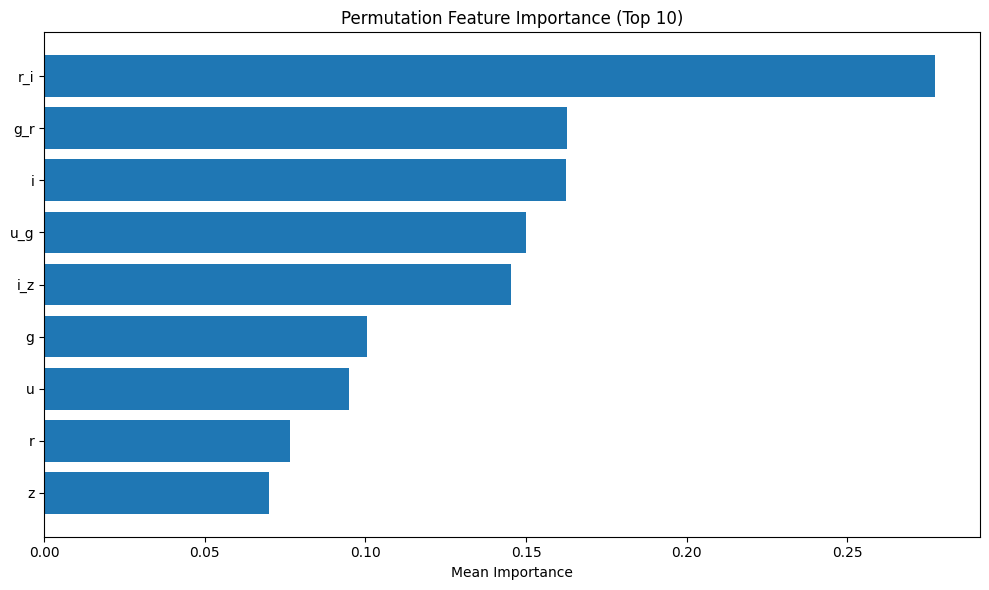

In [ ]:
# Feature importance for the best NN model using permutation importance

wrapped_model = sc.TorchModelWrapper(best_model_row["trained_model"], sc.device)

imp = sc.compute_permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    feature_names=feature_names,
    n_jobs=1
)

sc.plot_permutation_importance(imp, top_n=10)


In [ ]:
# Feature ablation for the best NN model

best_model_row = final_sorted.iloc[0]

importance_scores = imp

ablation_results = sc.run_feature_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    feature_names=feature_names,
    best_model_row=best_model_row,
    input_size=X_train.shape[1],
    num_classes=num_classes,
    device=sc.device,
    importance_scores=importance_scores,
    epochs=15
)

ablation_results


Best model: MediumNN | lr=0.001 | dropout=0.0

Training with top-1 features: ['r_i']
Epoch 1/15 | loss=0.8148 | train_acc=60.85% | val_acc=72.21%
Epoch 2/15 | loss=0.8046 | train_acc=61.90% | val_acc=71.19%
Epoch 3/15 | loss=0.8036 | train_acc=62.09% | val_acc=72.26%
Epoch 4/15 | loss=0.8035 | train_acc=62.23% | val_acc=72.32%
Epoch 5/15 | loss=0.8031 | train_acc=62.27% | val_acc=72.60%
Epoch 6/15 | loss=0.8025 | train_acc=62.28% | val_acc=72.48%
Epoch 7/15 | loss=0.8024 | train_acc=62.29% | val_acc=71.92%
Epoch 8/15 | loss=0.8021 | train_acc=62.31% | val_acc=72.35%
Epoch 9/15 | loss=0.8019 | train_acc=62.26% | val_acc=72.53%
Epoch 10/15 | loss=0.8018 | train_acc=62.25% | val_acc=72.51%
Epoch 11/15 | loss=0.8021 | train_acc=62.35% | val_acc=71.96%
Epoch 12/15 | loss=0.8015 | train_acc=62.38% | val_acc=72.44%
Epoch 13/15 | loss=0.8014 | train_acc=62.40% | val_acc=71.65%
Epoch 14/15 | loss=0.8011 | train_acc=62.44% | val_acc=72.36%
Epoch 15/15 | loss=0.8010 | train_acc=62.38% | val_acc=

,n_features,features,val_f1,test_f1
0,1,[r_i],0.625688,0.629117
1,2,"[r_i, g_r]",0.758687,0.762426
2,3,"[r_i, g_r, i]",0.809972,0.807690
3,4,"[r_i, g_r, i, u_g]",0.843202,0.846724
4,5,"[r_i, g_r, i, u_g, i_z]",0.855100,0.861827
5,6,"[r_i, g_r, i, u_g, i_z, g]",0.857473,0.864709
6,7,"[r_i, g_r, i, u_g, i_z, g, u]",0.857688,0.861806
7,8,"[r_i, g_r, i, u_g, i_z, g, u, r]",0.853202,0.861347
8,9,"[u, g, r, i, z, u_g, g_r, r_i, i_z]",0.855474,0.863060


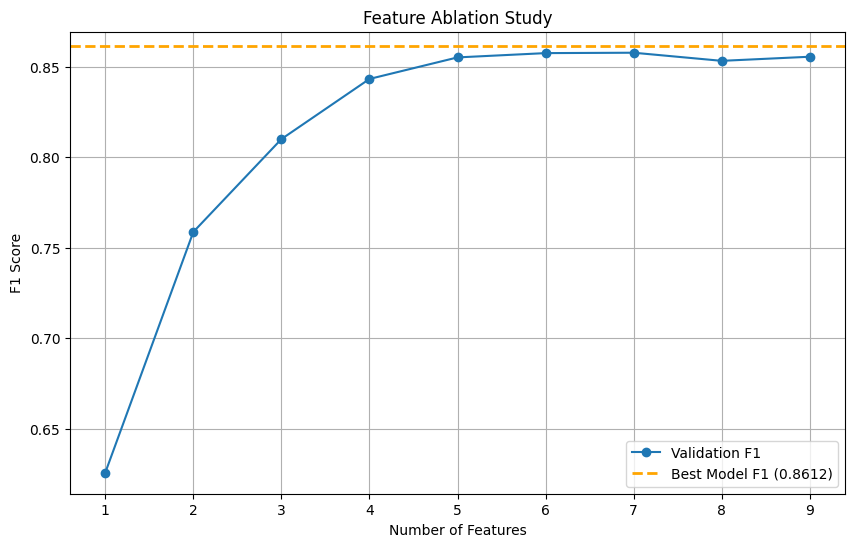

In [18]:
best_val_f1 = final_sorted.iloc[0]["val_f1"]

sc.plot_feature_ablation_nn(
    ablation_results,
    best_val_f1=best_val_f1
)

In [19]:
best_subset = sc.get_feature_subset_threshold(
    ablation_results,
    best_val_f1=best_model_row["val_f1"],
    threshold=0.95,
)

if best_subset is not None:
    print("\n===== 95% FEATURE SUBSET =====")
    print(f"Target F1       : {0.95 * best_model_row['val_f1']:.4f}")
    print(f"Reached F1      : {best_subset['val_f1']:.4f}")
    print(f"N. features     : {best_subset['n_features']}")
    print("\nSelected features:")
    for f in best_subset["features"]:
        print(f" - {f}")
else:
    print("No subset reached the required threshold.")


===== 95% FEATURE SUBSET =====
Target F1       : 0.8182
Reached F1      : 0.8432
N. features     : 4

Selected features:
 - r_i
 - g_r
 - i
 - u_g


In [20]:
print(
    f"Relative performance: "
    f"{100 * best_subset['val_f1'] / best_model_row['val_f1']:.2f}%"
)


Relative performance: 97.91%


## NN PCA

Outliers removed: 8,715 rows  (91,285 remain)

PCA ENABLED
Original features: 9
PCA components: 9
Explained variance: 100.00%


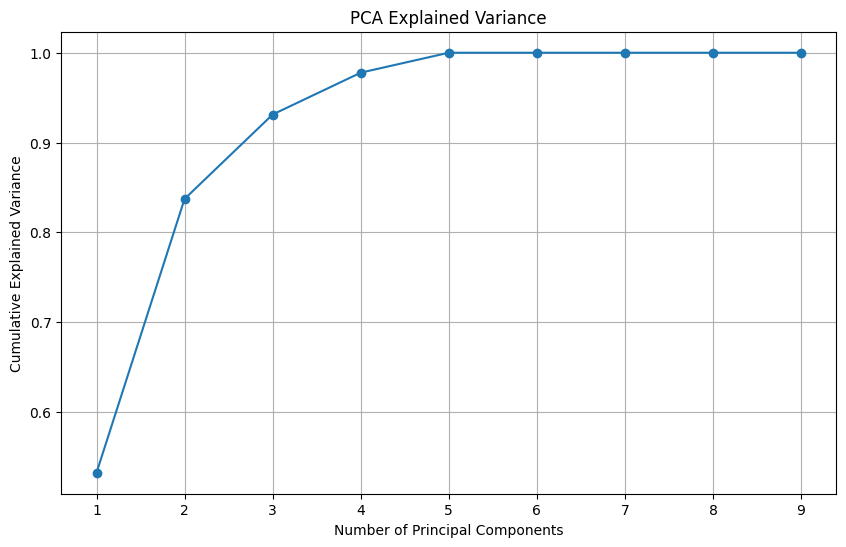

In [21]:
# PCA preprocessing

(
    X_train_pca,
    X_val_pca,
    X_test_pca,
    y_train_pca,
    y_val_pca,
    y_test_pca,
    label_encoder_pca,
    scaler_pca,
    feature_names_pca,
    pca,
) = sc.prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True,

    # PCA
    apply_pca=True,
    n_components=None,
)

# Plot explained variance
sc.plot_explained_variance(pca)

In [22]:
# Best model
best_model_row = final_sorted.iloc[0]

# PCA ablation
pca_results = sc.run_pca_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,

    y_train=y_train,
    y_val=y_val,
    y_test=y_test,

    best_model_row=best_model_row,

    num_classes=num_classes,
    device=sc.device,

    component_list=list(range(1, X_train.shape[1] + 1)),

    epochs=15,
)

display(pca_results)


PCA Experiment | components=1
Explained variance: 50.75%
Epoch 1/15 | loss=0.9751 | train_acc=51.32% | val_acc=48.61%
Epoch 2/15 | loss=0.9713 | train_acc=51.42% | val_acc=42.24%
Epoch 3/15 | loss=0.9709 | train_acc=51.35% | val_acc=43.61%
Epoch 4/15 | loss=0.9701 | train_acc=51.49% | val_acc=42.21%
Epoch 5/15 | loss=0.9696 | train_acc=51.47% | val_acc=43.62%
Epoch 6/15 | loss=0.9699 | train_acc=51.40% | val_acc=43.00%
Epoch 7/15 | loss=0.9695 | train_acc=51.53% | val_acc=44.17%
Epoch 8/15 | loss=0.9693 | train_acc=51.40% | val_acc=47.93%
Epoch 9/15 | loss=0.9694 | train_acc=51.49% | val_acc=42.63%
Epoch 10/15 | loss=0.9691 | train_acc=51.47% | val_acc=45.25%
Epoch 11/15 | loss=0.9691 | train_acc=51.45% | val_acc=43.57%
Epoch 12/15 | loss=0.9692 | train_acc=51.47% | val_acc=40.92%
Epoch 13/15 | loss=0.9691 | train_acc=51.47% | val_acc=42.27%
Epoch 14/15 | loss=0.9689 | train_acc=51.44% | val_acc=42.37%
Epoch 15/15 | loss=0.9688 | train_acc=51.49% | val_acc=42.03%

PCA Experiment | com

,n_components,explained_variance,val_f1,test_f1
0,1,0.507493,0.420479,0.417952
1,2,0.843796,0.720730,0.718237
2,3,0.930232,0.821247,0.820091
3,4,0.980349,0.840669,0.839424
4,5,1.000000,0.857951,0.863240
5,6,1.000000,0.854486,0.860199
6,7,1.000000,0.856416,0.861862
7,8,1.000000,0.854097,0.860921
8,9,1.000000,0.855742,0.861368


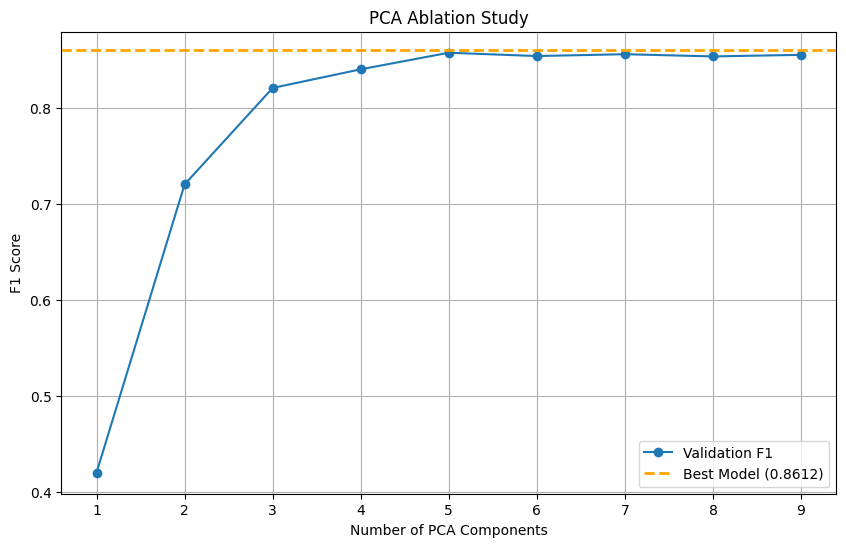

In [23]:
sc.plot_pca_ablation(
    pca_results,
    best_val_f1=best_model_row["val_f1"],
)

# Voting and Stacking

In [ ]:
SEED = 42


# Initialize and train the models for the ensemble (using the best models from each type)
svc_model = LinearSVC(random_state=SEED)
svc_model.fit(X_train, y_train)
calibrated_svc = CalibratedClassifierCV(svc_model, cv=5)
calibrated_svc.fit(X_train, y_train)
xgb_params = xgb_final.get_params()
xgb_params.pop('early_stopping_rounds', None)  # remove early stopping
xgb_for_ensemble = XGBClassifier(**xgb_params)

models = {
    'Linear SVC':    calibrated_svc,
    'Random Forest': rf_model,
    'Extra Trees':   et_model,
    'XGBoost':       xgb_for_ensemble,
    'LightGBM':      lgbm_final,
}

In [ ]:
# Train the voting classifier

voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models, voting='hard')

Voting Classifier trained.
  [Training] Acc=95.8962%  P=0.9592  R=0.9590  F1=0.9590
  [Validation] Acc=88.8755%  P=0.8591  R=0.8622  F1=0.8597


In [ ]:
warnings.filterwarnings('ignore')

# Perform 3-fold cross-validation on the combined training and validation set
X_search = np.concatenate([X_train, X_val], axis=0)
y_search = np.concatenate([y_train, y_val], axis=0)
print(f"X_search shape is: {X_search.shape} \ny_search shape is: {y_search.shape}")

cv_results = cross_validate(
    voting_clf,
    X_search, 
    y_search,
    cv=3,
    scoring='f1_weighted',
    n_jobs=3,
    return_train_score=True
)

print("Hard Voting - 3-fold Cross Validation:")
print(f"  Train F1: {cv_results['train_score'].mean():.4f} ± {cv_results['train_score'].std():.4f}")
print(f"  Val F1:   {cv_results['test_score'].mean():.4f} ± {cv_results['test_score'].std():.4f}")
print(f"  Gap:      {abs(cv_results['train_score'].mean() - cv_results['test_score'].mean()):.4f}")


X_search shape is: (115289, 9) 
y_search shape is: (115289,)


Hard Voting - 3-fold Cross Validation:
  Train F1: 0.9551 ± 0.0029
  Val F1:   0.9082 ± 0.0053
  Gap:      0.0469


In [ ]:
# Hyperparameter tuning for Stacking Classifier

stacking_clf_base = sc.make_stacking_classifier(models=models, n_jobs=3)
param_grid = {
    'final_estimator__C': [0.1, 1, 10],
    'cv': [5],
}
grid = GridSearchCV(
    estimator=stacking_clf_base, param_grid=param_grid,
    scoring='f1_weighted', cv=3, verbose=2, n_jobs=3, return_train_score=True
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

# training of Stacking Classifier with optimal parameters
stacking_clf = sc.train_stacking(
    X_train, y_train, X_val, y_val,
    models=models,
    cv=grid.best_params_['cv'],
    final_estimator=LogisticRegression(C=grid.best_params_['final_estimator__C'], max_iter=1000, random_state=SEED)
)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END .......................cv=5, final_estimator__C=0.1; total time=14.4min
[CV] END .......................cv=5, final_estimator__C=0.1; total time=14.5min
[CV] END .......................cv=5, final_estimator__C=0.1; total time=14.9min
[CV] END .........................cv=5, final_estimator__C=1; total time=13.0min
[CV] END .........................cv=5, final_estimator__C=1; total time=13.1min
[CV] END .........................cv=5, final_estimator__C=1; total time=13.0min
[CV] END ........................cv=5, final_estimator__C=10; total time=13.1min
[CV] END ........................cv=5, final_estimator__C=10; total time=13.1min
[CV] END ........................cv=5, final_estimator__C=10; total time=12.7min
Best params: {'cv': 5, 'final_estimator__C': 10}
Starting stacking training...
Stacking Classifier trained.
  [Training] Acc=98.6850%  P=0.9868  R=0.9868  F1=0.9868
  [Validation] Acc=88.5140%  P=0.8528  R=0.8567

In [ ]:
# Evaluation of voting and stacking classifiers on the test set

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)


Voting Classifier:
  Accuracy  : 89.03%
  Precision: 0.8592
  Recall   : 0.8649
  F1       : 0.8614
  Confusion Matrix:
[[10050   399   332]
 [  246  3050   252]
 [  370   404  3154]]

Stacking Classifier:
  Accuracy  : 88.95%
  Precision: 0.8574
  Recall   : 0.8625
  F1       : 0.8597
  Confusion Matrix:
[[10061   370   350]
 [  251  2990   307]
 [  367   373  3188]]


Meta-learner coefficients: weight of the vote


,svc_GALAXY,svc_QSO,svc_STAR,rf_GALAXY,rf_QSO,rf_STAR,et_GALAXY,et_QSO,et_STAR,xgb_GALAXY,xgb_QSO,xgb_STAR,lgbm_GALAXY,lgbm_QSO,lgbm_STAR
GALAXY,-0.375629,0.259699,0.139479,0.685916,-0.496137,-0.166231,0.673474,-0.300165,-0.349760,2.147395,-0.913994,-1.209853,-0.259461,0.084527,0.198482
QSO,0.427698,-0.918529,0.484715,-0.336635,1.277187,-0.946668,-0.289955,1.952988,-1.669149,-1.156700,3.083996,-1.933412,0.155459,-2.301566,2.139990
STAR,-0.052068,0.658830,-0.624194,-0.349280,-0.781050,1.112898,-0.383519,-1.652822,2.018909,-0.990695,-2.170002,3.143265,0.104001,2.217039,-2.338472


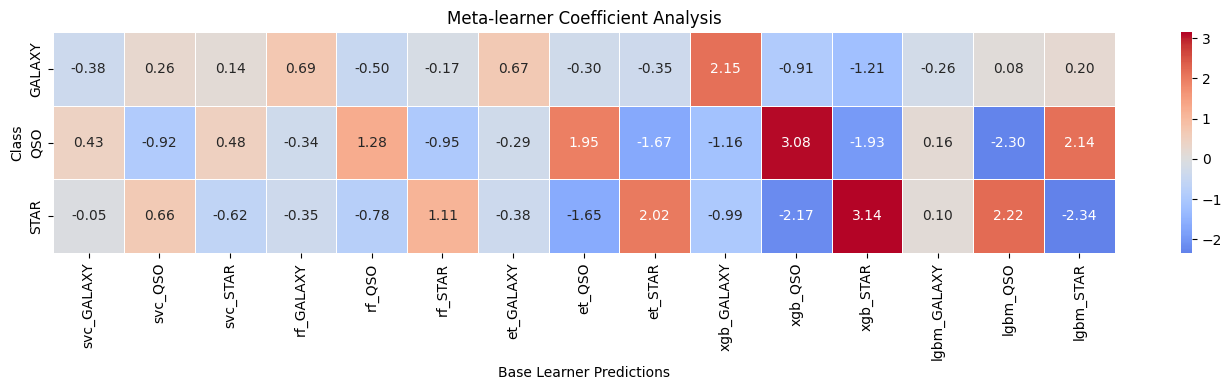

In [ ]:
# Analyze meta-learner coefficients for the stacking classifier

meta = stacking_clf.final_estimator_

col_names = [
    f"{name}_{cls}" 
    for name, _ in stacking_clf.estimators
    for cls in label_encoder.classes_
]

coef_df = pd.DataFrame(
    meta.coef_,
    columns=col_names,
    index=label_encoder.classes_
)

print("Meta-learner coefficients: weight of the vote")
display(coef_df)



fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    coef_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5
)

ax.set_title('Meta-learner Coefficient Analysis')
ax.set_xlabel('Base Learner Predictions')
ax.set_ylabel('Class')

plt.tight_layout()
plt.show()


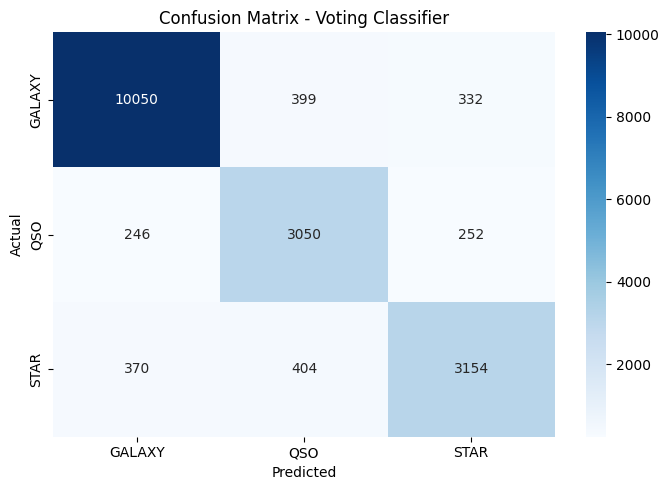

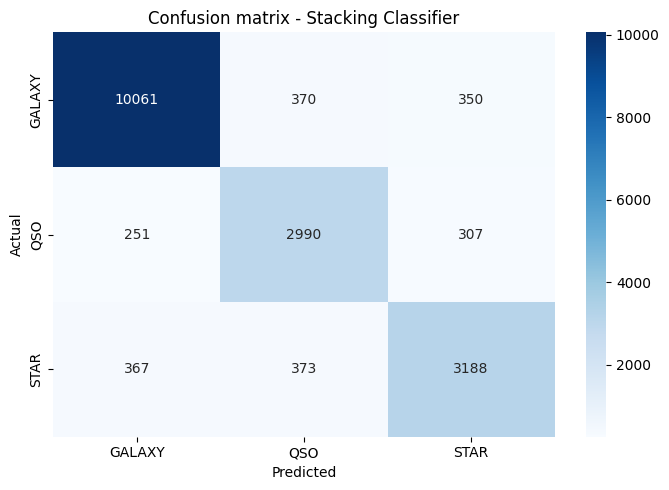

In [ ]:
# Confusion matrix for the best models of voting and stacking classifiers
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier')


In [ ]:
# Feature importance for the best models of voting and stacking classifiers using permutation importance

imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=4)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

plt.savefig("feature_importance_voting.pdf", dpi=300, bbox_inches="tight")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=4)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 



1 batch shape: 4000


## Best model analisys

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
  File "/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/xgboost

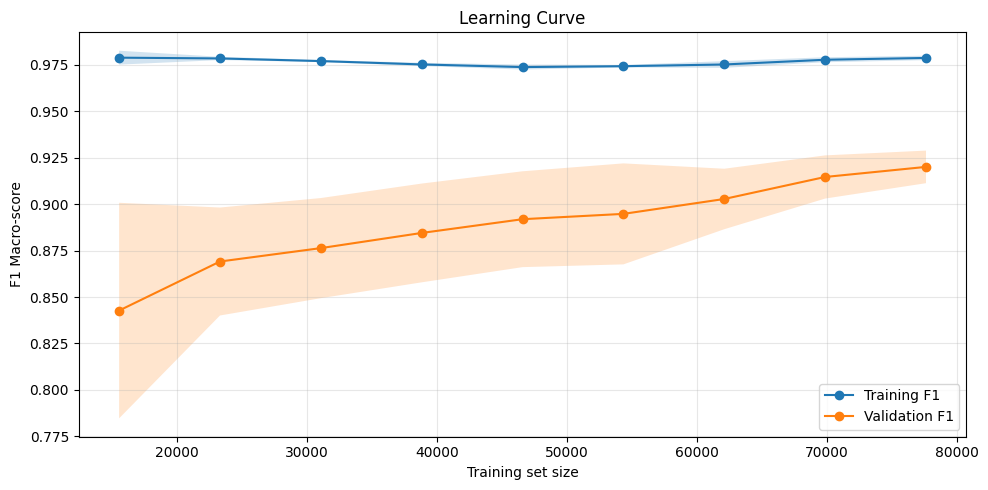

<Figure size 640x480 with 0 Axes>

In [ ]:
#learning curve for xgboost
xgb_lc = XGBClassifier(**xgb_final.get_params())

# removed early stopping
xgb_lc.set_params(early_stopping_rounds=None)

sc.plot_learning_curve(
    xgb_lc,
    X_train,
    y_train
)


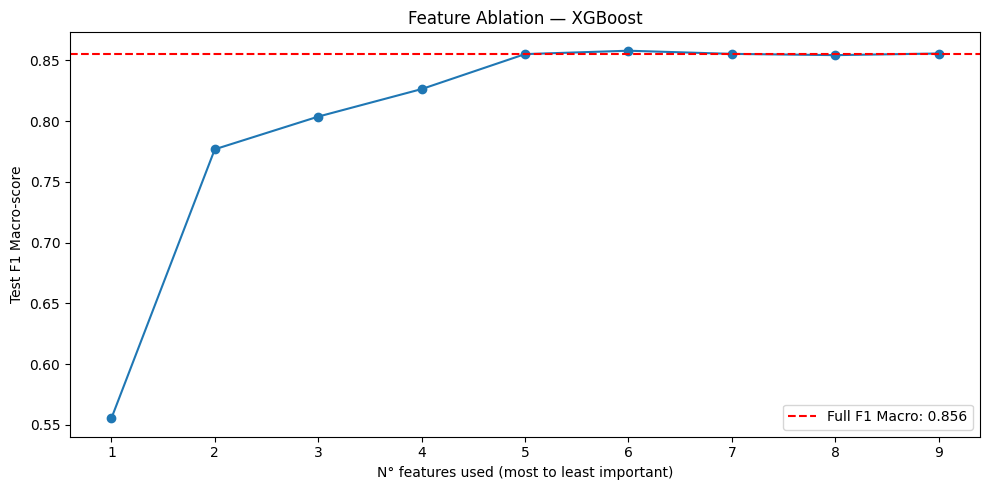

In [ ]:
#feature ablation for xgboost
fig, axes = plt.subplots(figsize=(10, 5))

xgb_ablation = XGBClassifier(
    n_estimators=1000,   
    max_depth=xgb_final.max_depth,
    learning_rate=xgb_final.learning_rate,
    subsample=xgb_final.subsample,
    colsample_bytree=xgb_final.colsample_bytree,
    random_state=42
)
xgb_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(xgb_ablation, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — XGBoost',
                         ax=axes)


plt.tight_layout()
plt.show()


          XGBoost — Prediction & Error Map


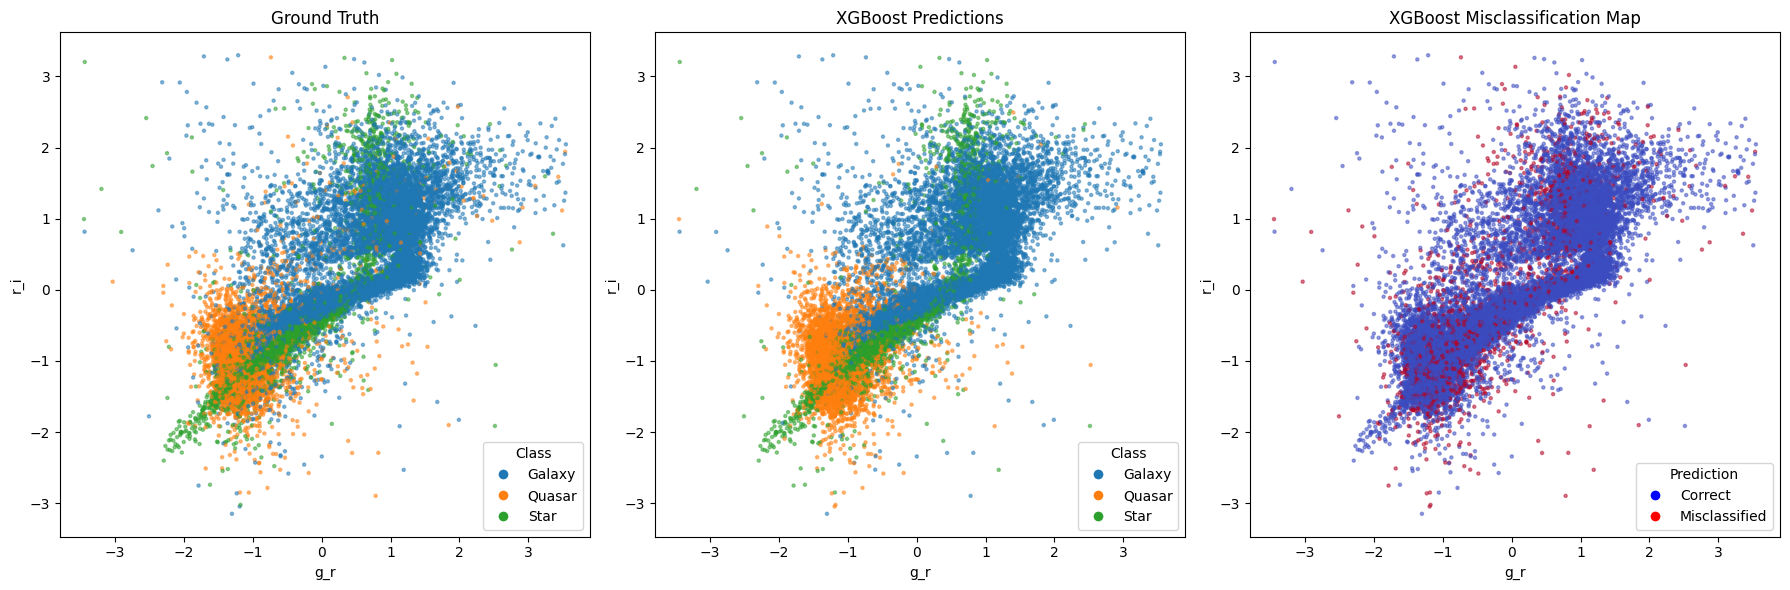

Figure(640x480)
          XGBoost — Prediction & Error Map


<Figure size 640x480 with 0 Axes>

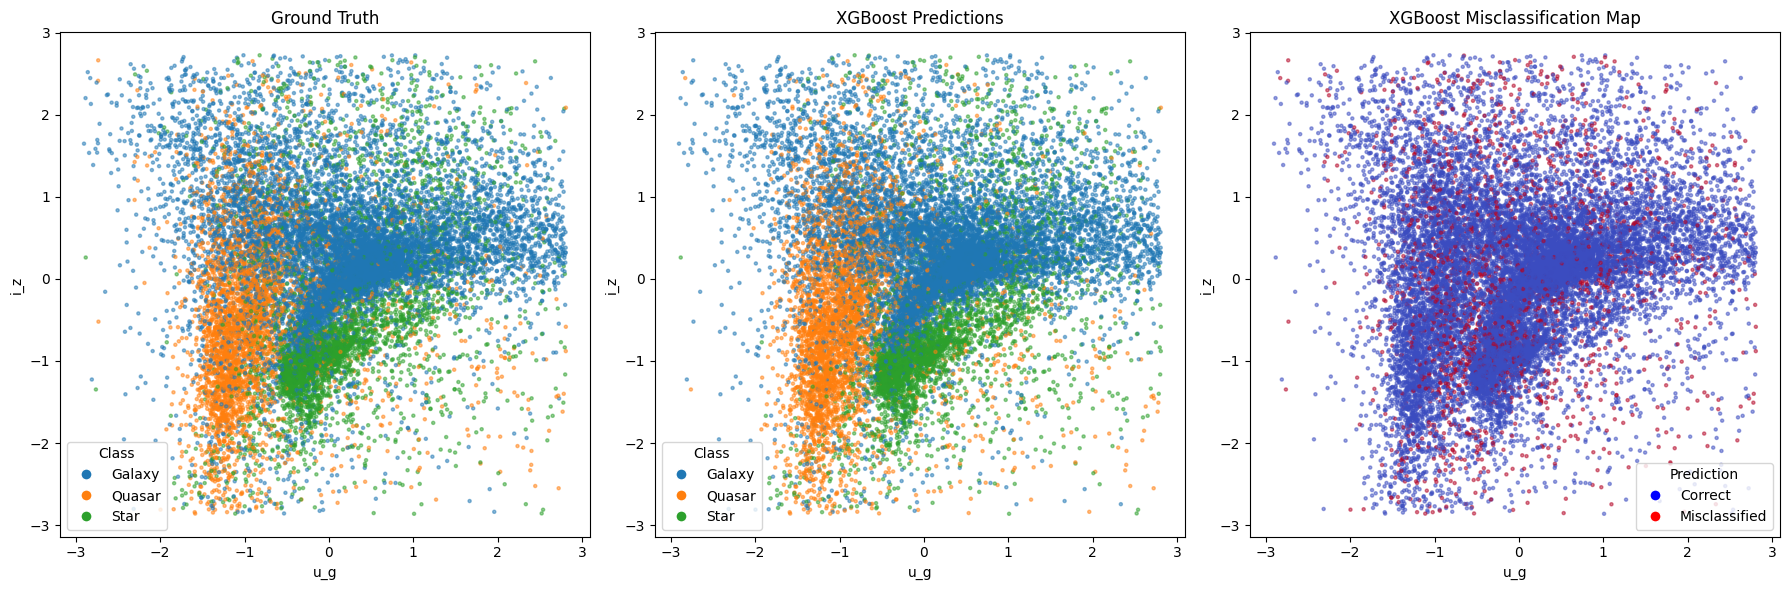

In [ ]:
# Plot prediction and error maps for XGBoost

print("          XGBoost — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost"
)


print("          XGBoost — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="XGBoost")


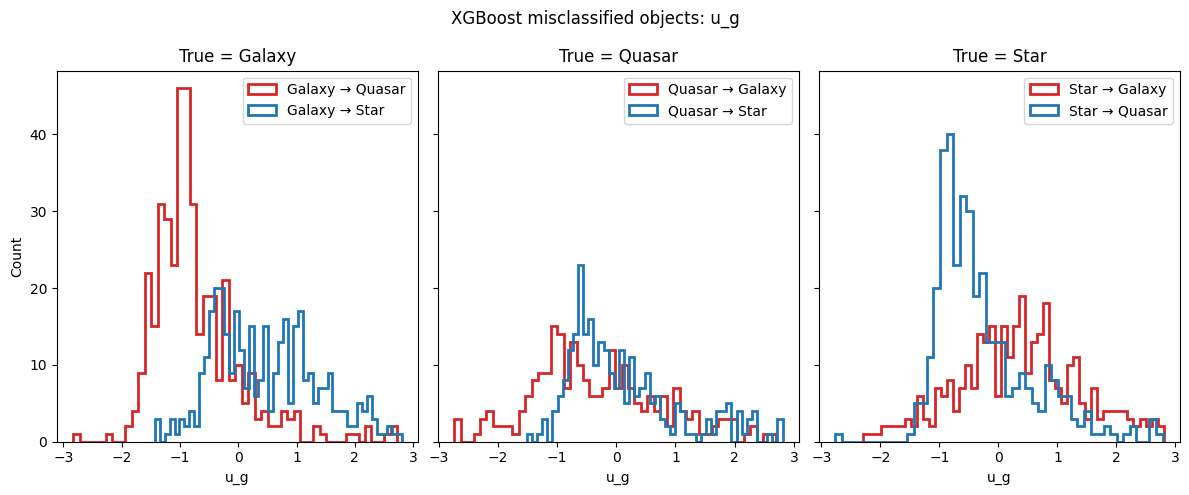

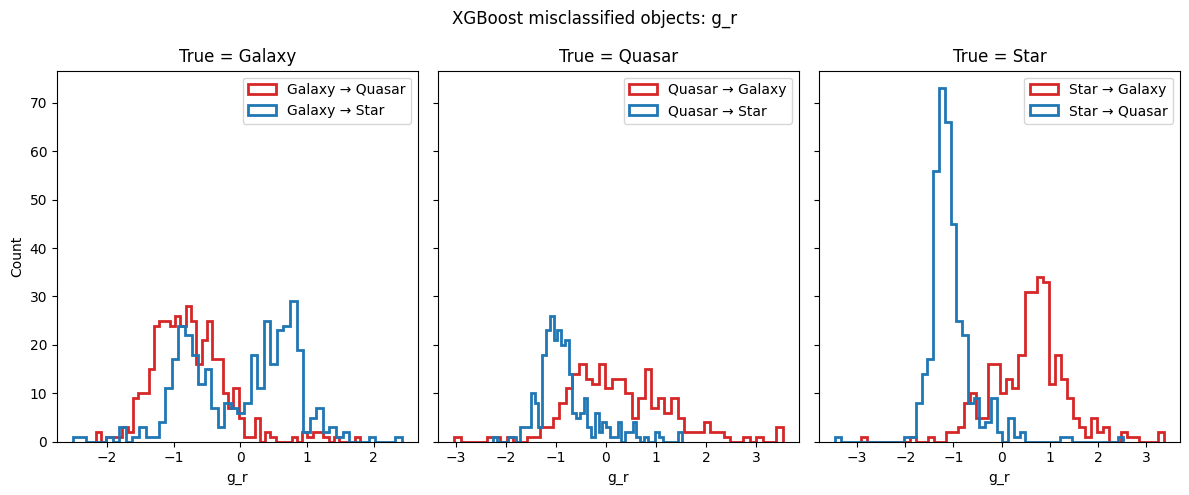

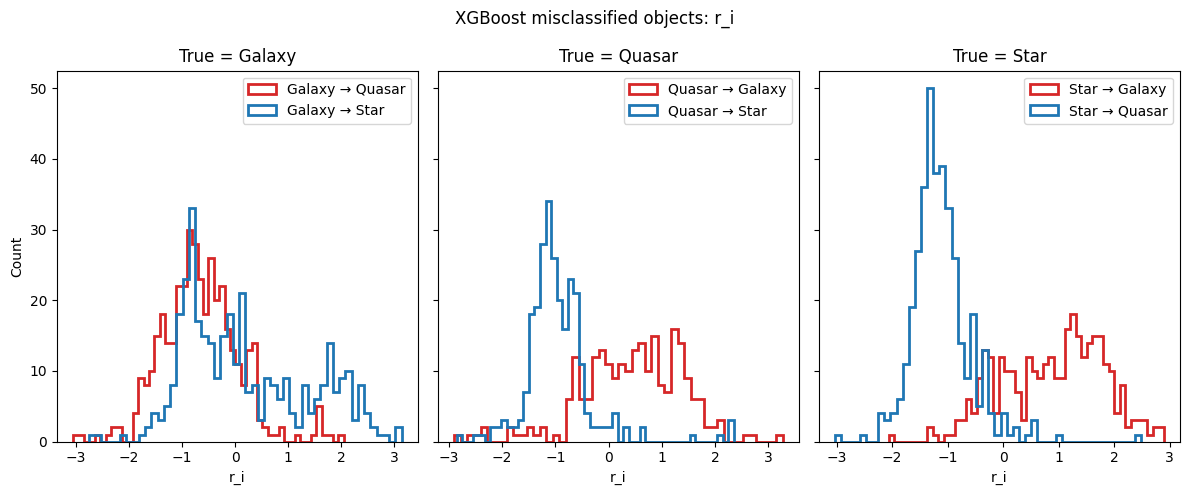

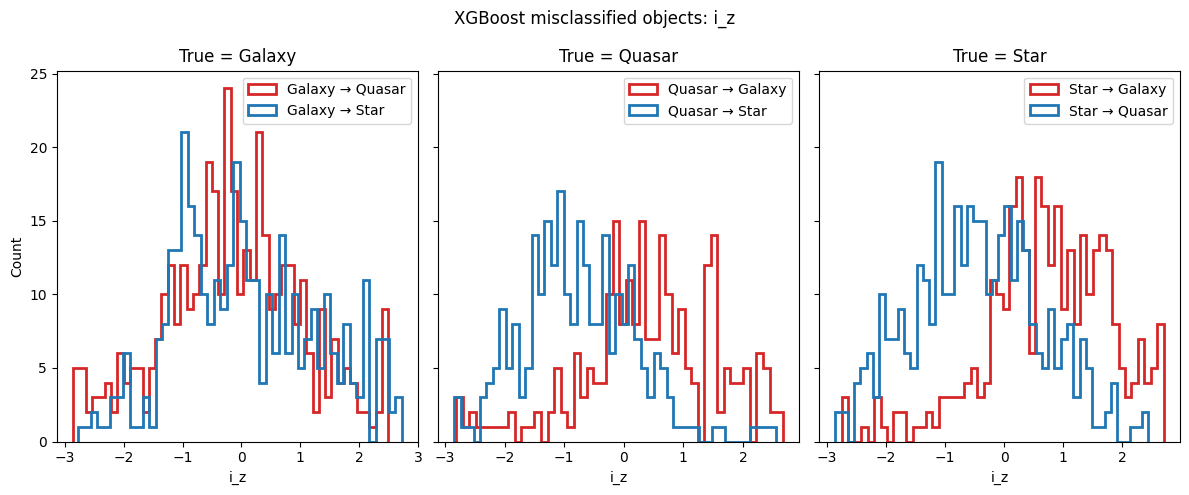

In [ ]:
# Plot misclassified feature distributions for XGBoost for the color indexes

sc.plot_misclassified_feature_distributions_separated(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"],
    prefix_name="XGBoost",

)

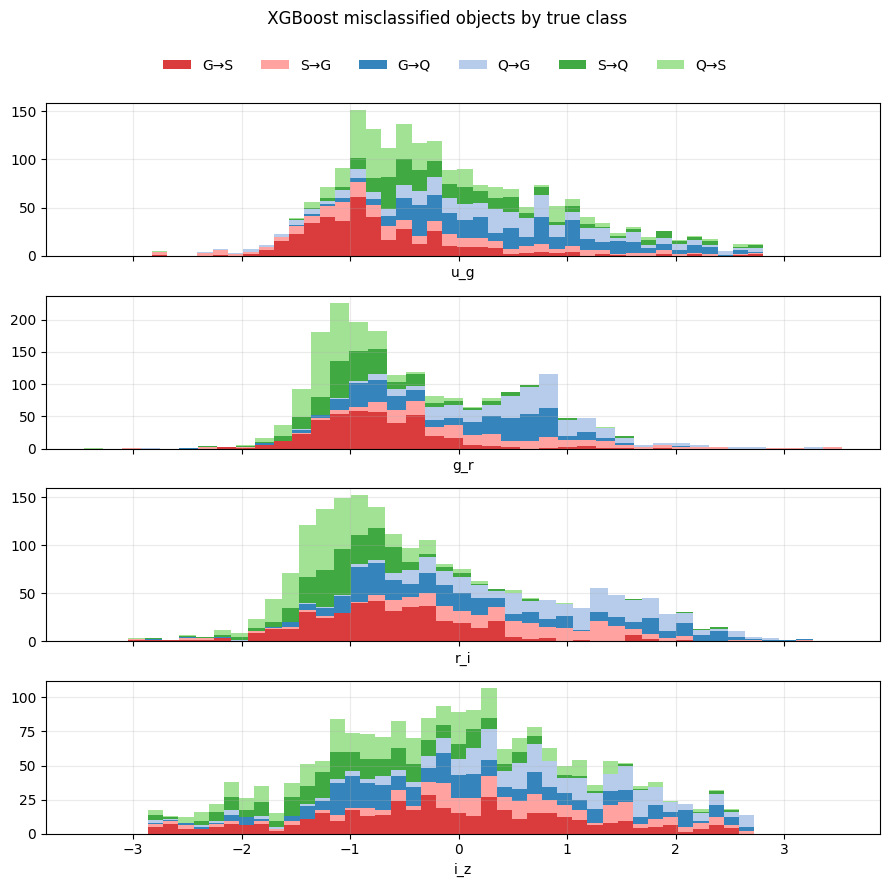

In [ ]:
# Plot misclassified feature distributions for XGBoost for the color indexes in a stacked histogram

sc.plot_misclassified_stacked_hist(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"],
    prefix_name="XGBoost"
)

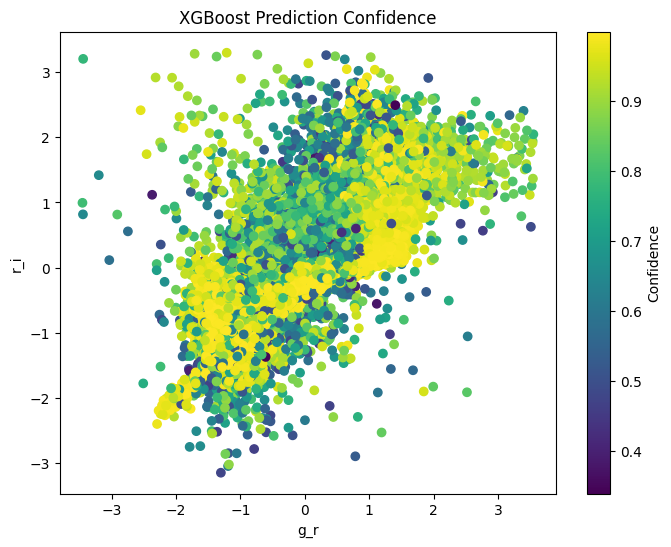

In [ ]:
# Predict with confidence for XGBoost and plot the results for the color indexes

results_xgb = sc.predict_with_confidence(
    model=xgb_final,
    X_test=X_test,
    X_plot=X_test_df,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost",
    threshold=0.9,
)

final_pred_xgb = results_xgb["final_predictions"]
confidence_xgb = results_xgb["confidence"]
